# ML in der Praxis · Gold-Standard-Skript

Ein bewusst **schlankes, lineares** Klassifikations-Skript nach dem Muster
*Laden → Aufteilen → Trainieren → Validieren → Evaluieren → Visualisieren → Speichern*.

**Leitidee:** Alles, was sich ändern kann (Datensatz **und** Algorithmus), steht im
`KONFIGURATION`-Block ganz oben. Der restliche Code wird **nicht angefasst** – er
liest nur aus `CONFIG`. So bleibt das Skript einfach *und* anpassbar zugleich.

> Didaktik vor Vollständigkeit: keine `try/except`-Kaskaden, keine defensive
> Programmierung – dafür ein Ablauf, den man Zeile für Zeile vorlesen kann.

In [ ]:
# === Installationen (einmalig, bei Bedarf einkommentieren) ===
%pip install scikit-learn pandas numpy matplotlib joblib gradio

In [8]:
####################################################
####  KONFIGURATION  –  hier (und nur hier!) anpassen
####################################################

CONFIG = {
    # --- Datensatz ----------------------------------------------------------
    "csv_pfad":    "Datasets/penguins_size_aufbereitet.csv",          # Pfad zur CSV
    "ziel_spalte": "sex",           # Was soll vorhergesagt werden?
    "ignorieren":  [],              # Spalten, die weder Ziel noch Merkmal sind
                                        #   (z. B. IDs). Leer lassen: []

    # --- Algorithmus  (EINE Zeile tauschen genügt) --------------------------
    "algorithmus": "logreg",            # logreg | baum | knn | wald

    # --- Aufteilung & Reproduzierbarkeit ------------------------------------
    "test_anteil": 0.2,                 # Anteil Test-Daten
    "cv_folds":    3,                   # Faltungen der Kreuzvalidierung
    "seed":        42,                  # fester Zufallswert -> reproduzierbar
}

# Register: Name aus CONFIG["algorithmus"] -> fertiges Modell-Objekt.
# Neuen Algorithmus ergänzen = eine Zeile hinzufügen.
from sklearn.linear_model   import LogisticRegression
from sklearn.tree           import DecisionTreeClassifier
from sklearn.neighbors      import KNeighborsClassifier
from sklearn.ensemble       import RandomForestClassifier

MODELL_REGISTER = {
    "logreg": LogisticRegression(max_iter=1000, random_state=CONFIG["seed"]),
    "baum":   DecisionTreeClassifier(random_state=CONFIG["seed"]),
    "knn":    KNeighborsClassifier(),
    "wald":   RandomForestClassifier(random_state=CONFIG["seed"]),
}

In [9]:
####################################################
####  HAUPTSKRIPT  –  liest nur aus CONFIG, nichts anpassen
####################################################

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler

SEED = CONFIG["seed"]

# --- SCHRITT 1: Daten laden -------------------------------------------------
df = pd.read_csv(CONFIG["csv_pfad"])
y  = df[CONFIG["ziel_spalte"]]
X  = df.drop(columns=[CONFIG["ziel_spalte"]] + CONFIG["ignorieren"])

# --- SCHRITT 2: Train-Test-Split (der "goldene Schnitt") --------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=CONFIG["test_anteil"], random_state=SEED, stratify=y
)

# --- SCHRITT 3: Pipeline bauen (Skalierung + gewähltes Modell) --------------
modell   = MODELL_REGISTER[CONFIG["algorithmus"]]
pipeline = Pipeline([
    ("scaler",     StandardScaler()),    # schadet keinem Modell, hilft vielen
    ("classifier", modell),
])

# --- SCHRITT 4: Kreuzvalidierung (Training & Validierung) -------------------
cv = StratifiedKFold(n_splits=CONFIG["cv_folds"], shuffle=True, random_state=SEED)
scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="accuracy")
print(f"Gewähltes Modell:           {CONFIG['algorithmus']}")
print(f"Genauigkeit je Fold:        {np.round(scores, 4)}")
print(f"Durchschnitt (Validierung): {scores.mean():.2%}  (+/- {scores.std():.2%})")

# --- SCHRITT 5: Finales Modell auf allen Trainingsdaten trainieren ----------
pipeline.fit(X_train, y_train)

# --- SCHRITT 6: Finale Evaluation auf dem Test-Set --------------------------
final_score = pipeline.score(X_test, y_test)
print(f"Genauigkeit (Test-Set):     {final_score:.2%}")

Gewähltes Modell:           logreg
Genauigkeit je Fold:        [0.9101 0.9213 0.9091]
Durchschnitt (Validierung): 91.35%  (+/- 0.56%)
Genauigkeit (Test-Set):     91.04%


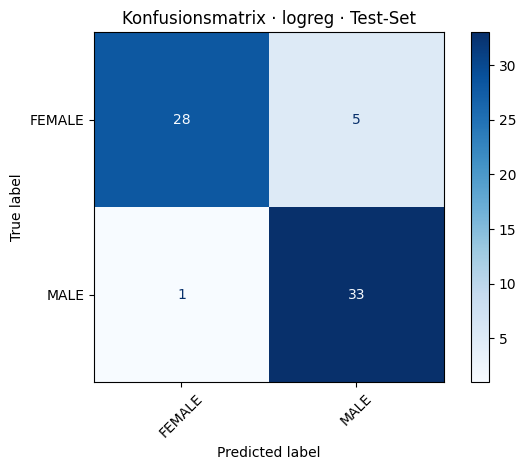

In [10]:
####################################################
####  DIE EINE VISUALISIERUNG  –  Konfusionsmatrix
####################################################
# Warum gerade diese? Sie zeigt nicht nur, WIE GUT das Modell ist, sondern
# WO es sich irrt (welche Klassen es verwechselt). Und sie funktioniert
# unabhaengig vom Algorithmus und von der Zahl der Merkmale - passt also
# zur selben Anpassbarkeit wie der Rest des Skripts.

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    pipeline, X_test, y_test, cmap="Blues", xticks_rotation=45
)
plt.title(f"Konfusionsmatrix · {CONFIG['algorithmus']} · Test-Set")
plt.tight_layout()
plt.show()

In [11]:
####################################################
####  MODELL SPEICHERN  (Vorbereitung Deployment)
####################################################
import joblib

joblib.dump(pipeline, "Models/meinModell.pkl")
print("Modell gespeichert als 'meinModell.pkl'.")

Modell gespeichert als 'meinModell.pkl'.


## Optional: Mini-Deployment mit Gradio

Auch diese Zelle bleibt **konfigurationsgetrieben** – Eingabefelder und Beschriftung
ergeben sich automatisch aus den Spalten von `X` und aus `CONFIG`. Wechselt man oben
den Datensatz, passt sich das Formular von selbst an (kein Hardcoding der Merkmale).

In [12]:
import gradio as gr
import joblib
import pandas as pd

model         = joblib.load("Models/meinModell.pkl")
feature_names = list(X.columns)          # kommt automatisch aus der KONFIGURATION

def vorhersage(*werte):
    # gleiche Spaltenreihenfolge wie im Training -> als DataFrame, sauber & warnungsfrei
    x = pd.DataFrame([werte], columns=feature_names)
    pred  = model.predict(x)[0]
    proba = model.predict_proba(x)[0]
    wahrscheinlichkeiten = {str(k): float(p) for k, p in zip(model.classes_, proba)}
    return str(pred), wahrscheinlichkeiten

inputs = [gr.Number(label=name) for name in feature_names]

demo = gr.Interface(
    fn=vorhersage,
    inputs=inputs,
    outputs=[gr.Textbox(label="Vorhersage"), gr.Label(label="Wahrscheinlichkeiten")],
    title="ML-Vorhersage",
    description=f"{CONFIG['algorithmus']}-Modell · Ziel: {CONFIG['ziel_spalte']}",
)

if __name__ == "__main__":
    # demo.launch()  # lokal
    demo.launch(inbrowser=True)

c:\Users\thoma\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
